*Autora: Rommina Terreros Cotera*

#**🛠️ Preparación de los Datos**

Extracción del Archivo Tratado

In [1]:
from google.colab import files
uploaded = files.upload()

Saving datos_tratados.csv to datos_tratados.csv


In [2]:
import pandas as pd

df = pd.read_csv("datos_tratados.csv")

In [4]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Churn_binary
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   object 
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 


In [6]:
df.describe()

,tenure,Charges.Monthly,Charges.Total,Churn_binary
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,0.265785
std,24.545260,30.085974,2266.771362,0.441782
min,1.000000,18.250000,18.800000,0.000000
25%,9.000000,35.587500,401.450000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.862500,3794.737500,1.000000
max,72.000000,118.750000,8684.800000,1.000000


Eliminación de Columnas Irrelevantes

In [7]:
df = df.drop(columns=["customerID"])

In [8]:
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Churn_binary
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1


Encoding

In [12]:
df.select_dtypes(include="object").columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [14]:
df_encoded.head()

,tenure,Charges.Monthly,Charges.Total,Churn_binary,Churn_Yes,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,9,65.6,593.30,0,False,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,9,59.9,542.40,0,False,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,4,73.9,280.85,1,True,True,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,13,98.0,1237.85,1,True,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,3,83.9,267.40,1,True,False,True,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [15]:
df_encoded.shape

(7032, 32)

Verificación de la Proporción de Cancelación (Churn)

In [16]:
df_encoded["Churn_binary"].value_counts()

,count
Churn_binary,
0,5163
1,1869


In [17]:
df_encoded["Churn_binary"].value_counts(normalize=True)

,proportion
Churn_binary,
0,0.734215
1,0.265785


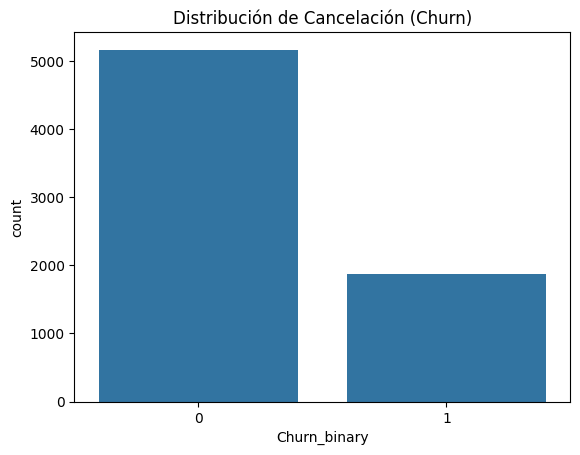

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn_binary", data=df_encoded)
plt.title("Distribución de Cancelación (Churn)")
plt.show()

*El dataset presenta un ligero desbalance en la variable objetivo, donde aproximadamente el 26.6% de los clientes cancelaron el servicio, mientras que el 73.4% permanecen activos. Este desbalance no es extremo, por lo que los modelos de clasificación pueden entrenarse sin aplicar técnicas de re-muestreo en esta etapa.*

# **🎯 Correlación y Selección de Variables**

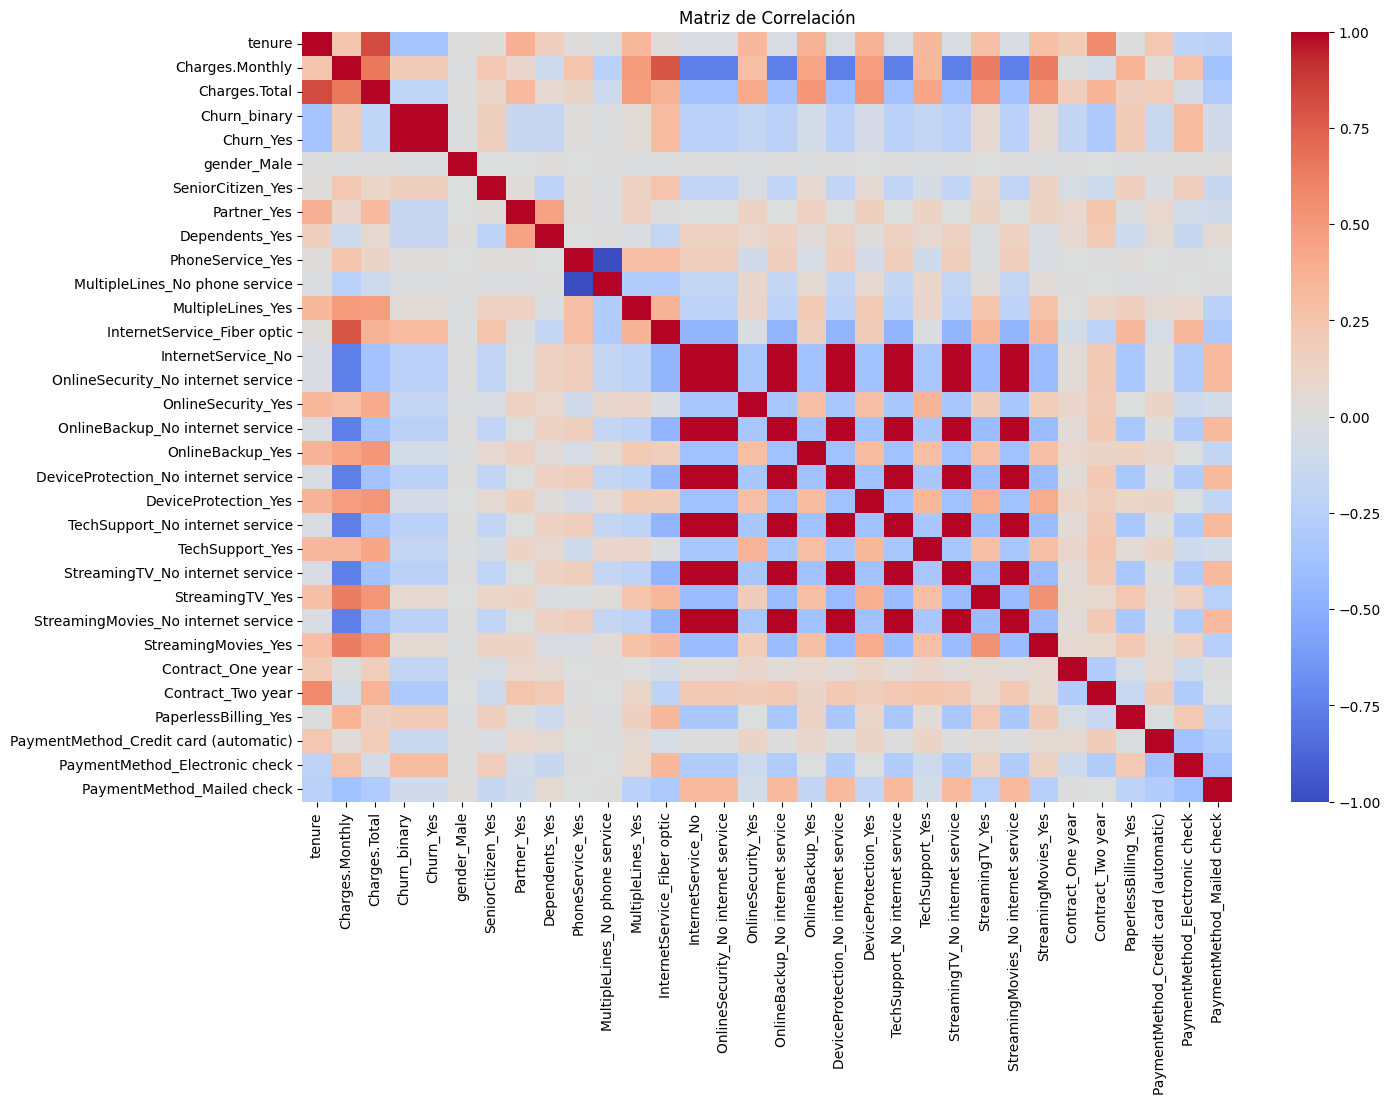

In [19]:
plt.figure(figsize=(15,10))
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

Bloques rojos fuertes
* OnlineSecurity_No internet service

* StreamingTV_No internet service

* DeviceProtection_No internet service

* StreamingMovies_No internet service

In [20]:
corr = df_encoded.corr()["Churn_binary"].sort_values(ascending=False)
corr

,Churn_binary
Churn_binary,1.000000
Churn_Yes,1.000000
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
Charges.Monthly,0.192858
PaperlessBilling_Yes,0.191454
SeniorCitizen_Yes,0.150541
StreamingTV_Yes,0.063254
StreamingMovies_Yes,0.060860
MultipleLines_Yes,0.040033


**Variables que AUMENTAN churn**

*Clientes con:*

* *fibra óptica*

* *pago con electronic check*

* *facturas altas*

* *facturación digital*

* *adultos mayores*

*tienden a cancelar más.*

**Variables que REDUCEN churn**
Los clientes que menos cancelan son los que:

* llevan más tiempo (tenure)
* tienen contratos largos
* tienen soporte técnico
* tienen seguridad online

In [21]:
df_encoded = df_encoded.drop(columns=["Churn_Yes"])

In [22]:
X = df_encoded.drop("Churn_binary", axis=1)
y = df_encoded["Churn_binary"]

In [23]:
print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


# **🤖 Modelado Predictivo**

Separación de Datos

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


## Creación de Modelos



### **Regresión Logística**

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

*Se aplicó estandarización utilizando StandardScaler antes de entrenar el modelo de Regresión Logística.*

*Este proceso transforma las variables para que tengan media 0 y desviación estándar 1, evitando que variables con magnitudes mayores (por ejemplo, Charges.Total) dominen el proceso de optimización del modelo.*

*La normalización es importante en modelos como Regresión Logística, KNN o SVM, ya que estos algoritmos se basan en distancias o en la optimización de coeficientes, y podrían verse sesgados si las variables tienen escalas muy diferentes.*

Evaluación del modelo

In [27]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [28]:
y_pred_log = log_model.predict(X_test_scaled)

Matriz de confusión

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.7960199004975125
Precision: 0.637223974763407
Recall: 0.5401069518716578
F1 Score: 0.5846599131693199


Interpretacion:
Accuracy (79.6%): El modelo clasifica correctamente 79.6% de los clientes, pero en churn prediction esta métrica no es la más importante.
Precision (63.7%): De todos los clientes que el modelo predijo como churn, el 63.7% realmente cancelaron
Recall (54%): El modelo detecta solo 54% de los clientes que realmente cancelan.
F1 Score (0.58): Balance entre precision y recall.

Sobre el modelo:
* clasifica bien clientes en general, pero pierde bastantes churners

Para una empresa esto significa que algunos clientes que van a cancelar no serían detectados para estrategias de retención.

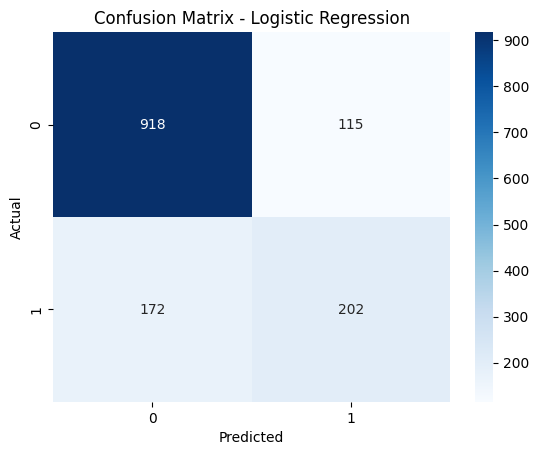

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### **Random Forest**

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [33]:
y_pred_rf = rf_model.predict(X_test)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7810945273631841
Precision: 0.6204379562043796
Recall: 0.45454545454545453
F1 Score: 0.5246913580246914


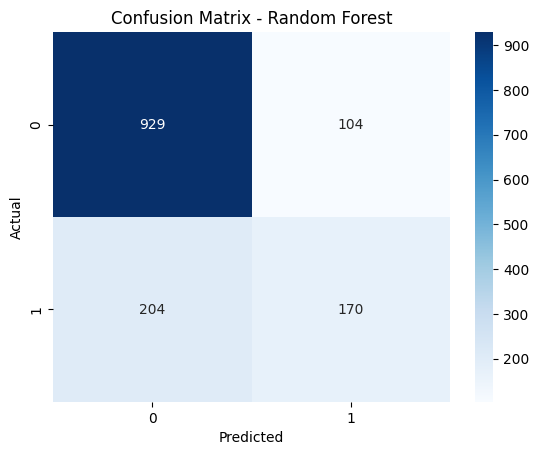

In [35]:
cm2 = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

*Mejor modelo*

Para este problema: **Regresión Logística** porque tiene mayor accuracy, mayor precision, mayor recall y mejor F1

# **Interpretación y Conclusiones**

Análisis de la Importancia de las Variables

In [36]:
import pandas as pd

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values(by="importance", ascending=False)

feature_importance.head(10)

,feature,importance
2,Charges.Total,0.191076
0,tenure,0.177776
1,Charges.Monthly,0.162452
28,PaymentMethod_Electronic check,0.040653
10,InternetService_Fiber optic,0.036915
25,Contract_Two year,0.031483
3,gender_Male,0.028691
26,PaperlessBilling_Yes,0.026357
13,OnlineSecurity_Yes,0.025455
5,Partner_Yes,0.023670


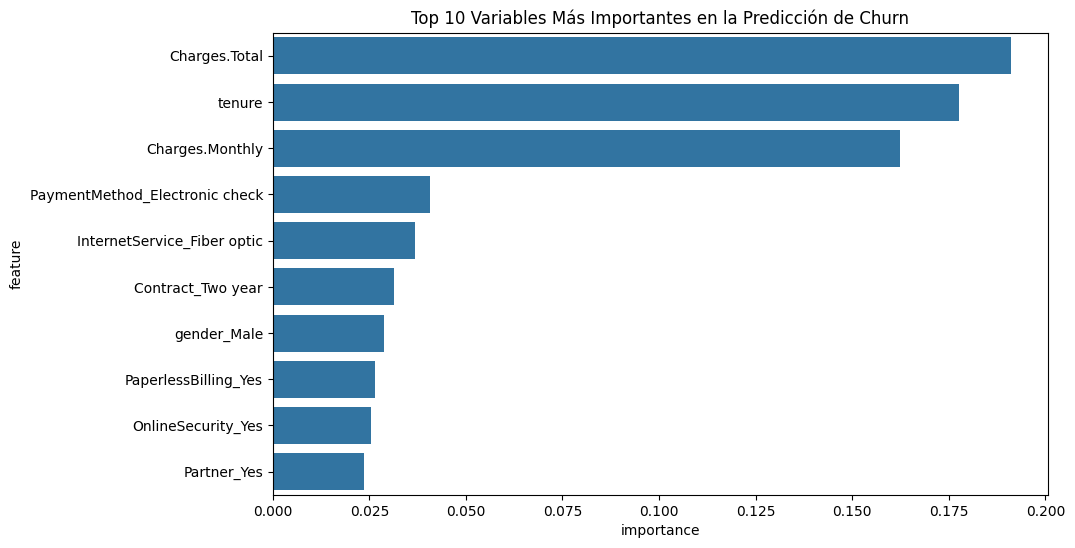

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Variables Más Importantes en la Predicción de Churn")
plt.show()

# Interpretación de los Resultados

El análisis de importancia de variables obtenido mediante el modelo **Random Forest** permite identificar los factores que tienen mayor influencia en la predicción de cancelación de clientes (*churn*).

Entre las variables más relevantes se encuentran **Charges.Total**, **tenure** y **Charges.Monthly**, lo que indica que los aspectos relacionados con el **costo del servicio y el tiempo de permanencia del cliente** tienen un impacto significativo en la decisión de cancelar el servicio.

- **Charges.Total** aparece como la variable más importante del modelo. Esto sugiere que el monto total que un cliente ha pagado a lo largo de su relación con la empresa está fuertemente asociado con su comportamiento de permanencia o cancelación.

- **tenure** (tiempo que el cliente lleva con la empresa) también muestra una alta relevancia. Esto indica que los clientes con menor tiempo de permanencia tienen una mayor probabilidad de cancelar el servicio.

- **Charges.Monthly** destaca como otro factor importante. Facturas mensuales más elevadas pueden aumentar la probabilidad de cancelación, posiblemente porque algunos clientes perciben el servicio como costoso en comparación con el valor recibido.

- Otras variables como **PaymentMethod_Electronic check**, **InternetService_Fiber optic** y **Contract_Two year** también influyen en el modelo, lo que sugiere que el tipo de servicio contratado, el método de pago y las condiciones del contrato pueden afectar el comportamiento de cancelación.



# Insights de Negocio

A partir de los resultados obtenidos del modelo de predicción de churn, se pueden identificar varios **insights estratégicos** que podrían ayudar a Telecom X a reducir la tasa de cancelación de clientes.

## 1. Fidelización de clientes en etapas tempranas

La importancia de la variable **tenure** indica que los clientes con menor tiempo en la empresa tienen mayor probabilidad de cancelar el servicio.

Por lo tanto, se recomienda:

- Implementar programas de bienvenida.
- Ofrecer promociones durante los primeros meses.
- Realizar seguimiento de satisfacción a nuevos clientes.

## 2. Optimización de la estructura de precios

El impacto de **Charges.Monthly** y **Charges.Total** sugiere que el costo del servicio es un factor relevante en la decisión de cancelación.

Posibles estrategias:

- Ofrecer planes más flexibles.
- Implementar promociones personalizadas.
- Evaluar paquetes de servicios con mejor relación costo-beneficio.

## 3. Promoción de contratos de largo plazo

El tipo de contrato también aparece como una variable influyente en el modelo.

Para mejorar la retención se podría:

- Incentivar contratos anuales o de mayor duración.
- Ofrecer descuentos o beneficios adicionales por contratos de largo plazo.

## 4. Incentivar métodos de pago más estables

El método de pago **Electronic check** muestra cierta relación con la probabilidad de churn.

Una posible estrategia sería:

- Incentivar métodos de pago automáticos.
- Ofrecer descuentos por pagos mediante débito automático o tarjeta.


### Conclusión

El análisis realizado mediante técnicas de **Machine Learning** permitió identificar los principales factores asociados a la cancelación de clientes (*churn*) en Telecom X.

En la evaluación de modelos predictivos, se compararon **Logistic Regression** y **Random Forest**. Los resultados muestran que el modelo de **Logistic Regression presentó un mejor desempeño general**, obteniendo las siguientes métricas:

- **Accuracy:** 0.796  
- **Precision:** 0.637  
- **Recall:** 0.540  
- **F1 Score:** 0.585  

Por su parte, el modelo **Random Forest** obtuvo:

- **Accuracy:** 0.781  
- **Precision:** 0.620  
- **Recall:** 0.455  
- **F1 Score:** 0.525  

Estos resultados indican que **Logistic Regression logra identificar mejor a los clientes con riesgo de cancelación**, especialmente considerando el **Recall**, que es una métrica clave en problemas de *churn prediction*, ya que mide la capacidad del modelo para detectar clientes que efectivamente cancelarán el servicio.

Adicionalmente, el análisis de importancia de variables mediante Random Forest permitió identificar los factores más influyentes en la predicción del churn. Entre las variables más relevantes destacan:

- **Charges.Total (0.191)**
- **tenure (0.178)**
- **Charges.Monthly (0.162)**
- **PaymentMethod_Electronic check (0.041)**
- **InternetService_Fiber optic (0.037)**

Estos resultados sugieren que **el costo del servicio, el tiempo de permanencia del cliente y algunas características del servicio contratado** influyen significativamente en la probabilidad de cancelación.

## Clientes con mayor riesgo de evasión

A partir de las variables más relevantes del modelo, se puede identificar que los clientes con mayor riesgo de cancelación suelen presentar las siguientes características:

- **Bajo tiempo de permanencia en la empresa (tenure bajo)**  
- **Facturas mensuales relativamente altas (Charges.Monthly)**  
- **Uso del método de pago Electronic Check**  
- **Clientes con ciertos tipos de servicio de internet como Fiber Optic**  
- **Clientes sin una relación consolidada con la empresa**

Esto sugiere que los **clientes nuevos y con costos de servicio más elevados** tienden a ser más propensos a cancelar el servicio.

## Variables que más influyen en el comportamiento de churn

El modelo identificó como variables más influyentes:

- **Charges.Total**
- **tenure**
- **Charges.Monthly**

Estas variables reflejan principalmente **el nivel de gasto del cliente y la duración de su relación con la empresa**, lo que indica que el comportamiento de churn está fuertemente relacionado con factores económicos y con la estabilidad de la relación cliente-empresa.

## Perfil de cliente que la empresa debería fomentar

De acuerdo con los resultados del modelo, Telecom X podría enfocarse en atraer y retener clientes con el siguiente perfil:

- **Clientes con mayor permanencia en el servicio**
- **Clientes que adopten contratos de largo plazo**
- **Clientes con métodos de pago automáticos o más estables**
- **Clientes que perciban un equilibrio entre el costo del servicio y el valor recibido**

Fomentar este tipo de perfil puede contribuir a **reducir la tasa de cancelación y aumentar la estabilidad de los ingresos de la empresa**.

En conjunto, estos hallazgos demuestran que el uso de técnicas de **análisis de datos y aprendizaje automático** permite comprender mejor el comportamiento de los clientes e identificar patrones asociados al abandono del servicio. Esta información puede ser utilizada por Telecom X para diseñar **estrategias de retención más efectivas**, enfocadas en clientes nuevos, optimización de precios y programas de fidelización.